## Implement Logistic Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def single_proba(Xrow, W):
    assert len(W) > 1, "Unexpected W size. Function works with 2 or more features."
    assert len(Xrow) + 1 == len(W), "Invalid args. The sizes of X and W arrays are not consistent!"
    
    L = W[0]
    for i in range(1, len(W)):
        L += W[i] * Xrow[i-1]

    result = 1 / (1 + np.exp(-L))
    if np.isclose(result, 1):
        return 0.99999
    else:
        return result
    
def proba(X, W):
    result = []
    for Xrow in X:
        result.append(single_proba(Xrow, W))
    return result

def cost(preds, Ytrain):
    assert len(preds) == len(Ytrain), "Cost function invalid args!"
    sum = 0;
    for i in range(len(preds)):
        sum += Ytrain[i] * np.log(preds[i]) + (1-Ytrain[i]) * np.log(1-preds[i])
    return -1 * sum

    # Logloss derivative with respect to Wi
def logloss_der_wrt_w(w_index, Xtrain, Ytrain, probs):
    assert len(probs) == len(Ytrain), "Derivative function invalid args!"
    if w_index == 0:
        return (-1 / len(probs)) * np.sum(np.array(Ytrain) - np.array(probs))
    else:
        xi = Xtrain[:, w_index - 1 : w_index]
        return (-1 / len(probs)) * np.sum((np.array(Ytrain) - np.array(probs)) * np.array(xi))

def proba_to_pred(probs):
    return [1 if x > 0.5 else 0 for x in probs]

class LogReg:
    def __init__(self, lr = 0.1, epochs = 100, start_w = 1):
        self.__COSTS__ = []
        self.__PROBS__ = []
        self.__PREDS__ = []
        self.__PARAMS__ = []
        self.__LEARNING_RATE__ = lr
        self.__EPOCHS__ = epochs
        self.__START_W__ = start_w

    def fit(self, Xtrain, Ytrain):
        self.__COSTS__.clear()
        self.__PROBS__.clear()
        self.__PREDS__.clear()
        self.__PARAMS__.clear()
        
        assert len(Xtrain) > 1, "Fit invalid args!"
        assert len(Xtrain[0]) > 1, "Fit invalid args!"
        
        # Start values
        W = [self.__START_W__] * (len(Xtrain[0]) + 1)
        self.__PARAMS__.append(W.copy())
    
        for _ in range(self.__EPOCHS__):
            probs = proba(Xtrain, W)
            self.__PROBS__.append(probs)
            self.__PREDS__.append(proba_to_pred(probs))
            self.__COSTS__.append(cost(probs, Ytrain))

            for i in range(len(W)):
                W[i] -= self.__LEARNING_RATE__ * logloss_der_wrt_w(i, Xtrain, Ytrain, probs)
            
            self.__PARAMS__.append(W.copy())

    def predict(self, Xtest):
        assert len(self.__PARAMS__) > 1, "Model not trained!"
        return proba_to_pred(proba(Xtest, self.__PARAMS__[-1]))
    
    def accuracy_score(self, preds, Ytest):
        assert len(preds) > 0, "Invalid accuracy_score args!"
        assert len(preds) == len(Ytest), "Invalid accuracy_score args!"
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for i in range(len(preds)):
            if Ytest[i] == 0 and preds[i] == 0:
                tn+=1
            elif Ytest[i] == 0 and preds[i] == 1:
                fp+=1
            elif Ytest[i] == 1 and preds[i] == 0:
                fn+=1
            elif Ytest[i] == 1 and preds[i] == 1:
                tp+=1
            else:
                assert False, "Should not be here!"
        return (tp + tn) / (tp + tn + fp + fn)

## Import only utilities from sklearn

In [2]:
from sklearn import datasets, model_selection, preprocessing

## Load dataset and prepare train and test data

In [3]:
iris = datasets.load_iris()
X = iris.data[:, :2]

In [4]:
Y = iris.target

In [5]:
normalizer = preprocessing.Normalizer().fit(X)

X_train, X_test, Y_train, Y_test = model_selection.train_test_split(normalizer.transform(X), Y, test_size=0.2, random_state=42)

Y_train_1 = [1 if x == 0 else 0 for x in Y_train]
Y_test_1 = [1 if x == 0 else 0 for x in Y_test]

Y_train_2 = [1 if x == 1 else 0 for x in Y_train]
Y_test_2 = [1 if x == 1 else 0 for x in Y_test]

Y_train_3 = [1 if x == 2 else 0 for x in Y_train]
Y_test_3 = [1 if x == 2 else 0 for x in Y_test]

# print(Y_train_1[:20])
# print(Y_train_2[:20])
# print(Y_train_3[:20])

# print(Y_test_1[:20])
# print(Y_test_2[:20])
# print(Y_test_3[:20])

## Predict. Common case.

0.6666666666666666
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.7
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.6333333333333333
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


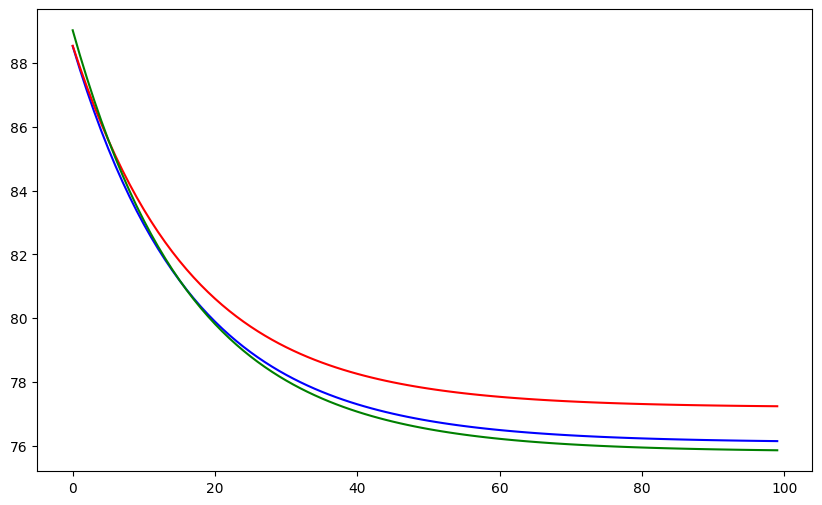

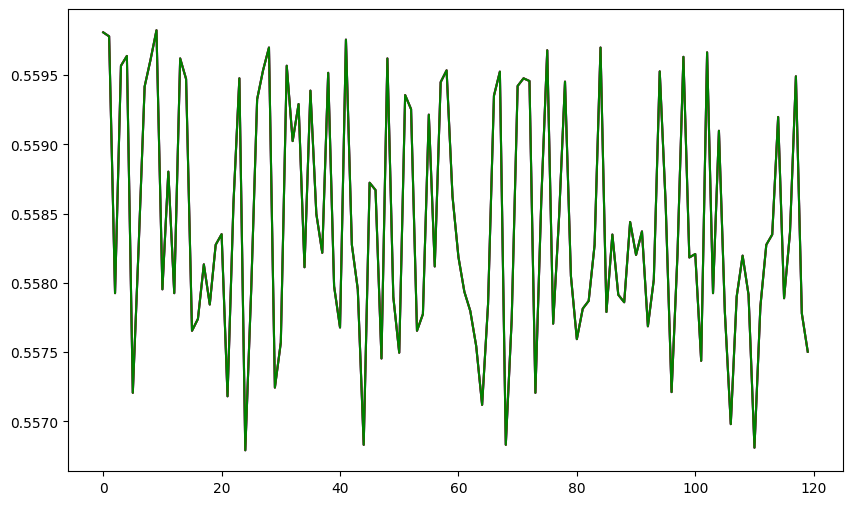

In [6]:
log_reg_cc_1 = LogReg(epochs = 100, lr = 0.001, start_w = 0.1)
log_reg_cc_1.fit(X_train, Y_train_1)
preds_cc_1 = log_reg_cc_1.predict(X_test)
score_cc_1 = log_reg_cc_1.accuracy_score(preds_cc_1, Y_test_1)

print(score_cc_1)
print(preds_cc_1[:20])

log_reg_cc_2 = LogReg(epochs = 100, lr = 0.001, start_w = 0.1)
log_reg_cc_2.fit(X_train, Y_train_2)
preds_cc_2 = log_reg_cc_2.predict(X_test)
score_cc_2 = log_reg_cc_2.accuracy_score(preds_cc_2, Y_test_2)

print(score_cc_2)
print(preds_cc_2[:20])

log_reg_cc_3 = LogReg(epochs = 100, lr = 0.001, start_w = 0.1)
log_reg_cc_3.fit(X_train, Y_train_3)
preds_cc_3 = log_reg_cc_3.predict(X_test)
score_cc_3 = log_reg_cc_3.accuracy_score(preds_cc_3, Y_test_3)

print(score_cc_3)
print(preds_cc_3[:20])

plt.figure(figsize=(10, 6))
plt.plot(log_reg_cc_1.__COSTS__, color = 'blue')
plt.plot(log_reg_cc_2.__COSTS__, color = 'red')
plt.plot(log_reg_cc_3.__COSTS__, color = 'green')
plt.show()

# Одинаковые вероятности почему-то...
plt.figure(figsize=(10, 6))
plt.plot(log_reg_cc_1.__PROBS__[0], color = 'blue')
plt.plot(log_reg_cc_2.__PROBS__[0], color = 'red')
plt.plot(log_reg_cc_3.__PROBS__[0], color = 'green')

plt.show()